In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from lib.data_quality import data_quality_report, apply_data_quality_rules
from lib.feature_selection import classification_woe_iv, calculate_classification_woe
from lib.probability_of_default import ProbabilityOfDefault
from lib.feature_selection import WoETransformer
from lib.feature_engineering import select_columns, log_loan_amount

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [4]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
df.describe(include="all")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


In [6]:
data_quality_report(df)

age > 100                  5
emp_length > age - 14      2
duplicate rows           165
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)
df = apply_data_quality_rules(df)
data_quality_report(df)

age > 100                0
emp_length > age - 14    0
duplicate rows           0
dtype: int64

In [8]:
target_col = "loan_status"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

X_train = X_train.reset_index(drop=True).copy()
X_test = X_test.reset_index(drop=True).copy()
y_train = y_train.reset_index(drop=True).copy()
y_test = y_test.reset_index(drop=True).copy()

In [9]:
print(
    "      |   X   | y\n"
    "––––––––––––––––––––––––\n"
    f"Train | {len(X_train)} | {len(y_train)}\n"
    f"Test  | {len(X_test)}  | {len(y_test)}\n"
)

      |   X   | y
––––––––––––––––––––––––
Train | 25932 | 25932
Test  | 6484  | 6484



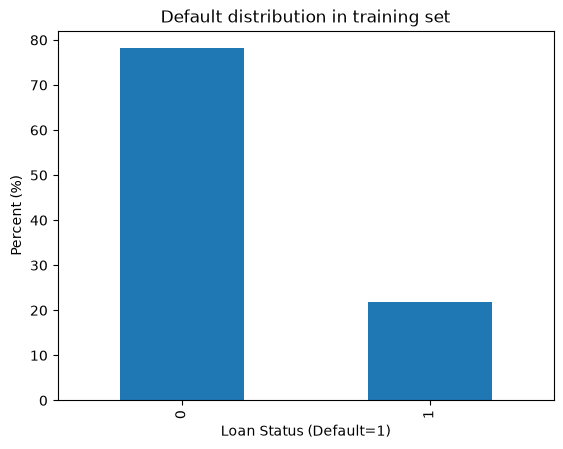

In [10]:
fig, ax = plt.subplots()

(y_train.value_counts(normalize=True)*100).plot(kind="bar", title="Default distribution in training set", ax=ax)

ax.set_xlabel("Loan Status (Default=1)")
ax.set_ylabel("Percent (%)")

plt.show()

In [11]:
iv, woe = classification_woe_iv(pd.concat([X_train, y_train], axis=1), target_col, show_woe=False)
woe

Information value of person_age is 0.011791
Information value of person_income is 0.453840
Information value of person_home_ownership is 0.383521
Information value of person_emp_length is 0.065899
Information value of loan_intent is 0.092562
Information value of loan_grade is 0.873417
Information value of loan_amnt is 0.090789
Information value of loan_int_rate is 0.662183
Information value of loan_percent_income is 0.879961
Information value of cb_person_default_on_file is 0.165054
Information value of cb_person_cred_hist_length is 0.004768


,Variable,Cutoff,N,Bads,Goods,% of Bads,% of Goods,WoE,IV
0,person_age,"(-inf, 22.0]",3865,1007,2858,0.177570,0.141059,-0.230186,8.404299e-03
1,person_age,"(22.0, 23.0]",3126,685,2441,0.120790,0.120478,-0.002588,8.080710e-07
2,person_age,"(23.0, 24.0]",2809,596,2213,0.105096,0.109225,0.038531,1.590770e-04
3,person_age,"(24.0, 25.0]",2432,543,1889,0.095750,0.093233,-0.026639,6.705004e-05
4,person_age,"(25.0, 26.0]",1985,417,1568,0.073532,0.077390,0.051138,1.972916e-04
...,...,...,...,...,...,...,...,...,...
83,cb_person_cred_hist_length,"(4.0, 5.0]",1478,295,1183,0.052019,0.058388,0.115501,7.356257e-04
84,cb_person_cred_hist_length,"(5.0, 7.0]",2986,604,2382,0.106507,0.117566,0.098789,1.092507e-03
85,cb_person_cred_hist_length,"(7.0, 9.0]",3063,646,2417,0.113913,0.119293,0.046150,2.483050e-04
86,cb_person_cred_hist_length,"(9.0, 11.0]",1812,368,1444,0.064892,0.071270,0.093757,5.980172e-04


In [12]:
feats = ["person_income", "person_home_ownership", "person_emp_length", "loan_intent",
         "loan_amnt", "loan_percent_income", "cb_person_default_on_file"]

In [13]:
woe_feats = [f for f in feats if f!="loan_amnt"]

In [ ]:
pipe = Pipeline([
    ("select",     FunctionTransformer(select_columns, kw_args={"columns": feats})),
    ("log_amount", FunctionTransformer(log_loan_amount)),
    ("woe",        WoETransformer(variables=woe_feats)),
    ("model",      LogisticRegression(class_weight="balanced", random_state=42)),
])

In [18]:
pod = ProbabilityOfDefault(pipe, X_train, X_test, y_train, y_test)

In [19]:
pod.cross_validation_metrics()

,Gini,ROC_AUC,PR_AUC,Precision,Brier_Score
Fold,,,,,
1,0.625370,0.812685,0.640609,0.640762,0.168842
2,0.633654,0.816827,0.644696,0.644859,0.168021
3,0.624960,0.812480,0.641118,0.641278,0.168080
4,0.650572,0.825286,0.663435,0.663562,0.169277
5,0.631070,0.815535,0.650574,0.650707,0.166129


In [20]:
pod.run_cv_calibration_tests()

{'hosmer_lemeshow': {'statistic': 5.6625126094250895,
  'df': 8,
  'p_value': 0.6849760757783616},
 'binomial_test_by_bin':    bin  total_n  observed_pos  expected_prob  observed_prob   p_value
 0    0     2581            48       0.016492       0.018597  0.394537
 1    1     2606           139       0.050683       0.053338  0.531712
 2    2     2581           223       0.077470       0.086401  0.090357
 3    3     2425           234       0.104237       0.096495  0.218946
 4    4     2742           332       0.123107       0.121080  0.771349
 5    5     2621           386       0.148929       0.147272  0.847707
 6    6     2532           532       0.204696       0.210111  0.506067
 7    7     2642           650       0.251679       0.246026  0.515694
 8    8     2599          1061       0.408495       0.408234  0.984084
 9    9     2603          2066       0.796598       0.793700  0.714962}

In [21]:
print(f"ROC AUC: {pod.roc_auc():.2f}")

ROC AUC: 0.81


In [22]:
print(f"PR AUC:   {pod.pr_auc():.2f}")

PR AUC:   0.65


In [23]:
print(f"Average precision:   {pod.average_precision():.2f}")

Average precision:   0.64


In [24]:
ginis = []
for seed in range(10):
    a, b, c, d = train_test_split(X[feats], y, stratify=y, test_size=0.2, random_state=seed)
    ginis.append(ProbabilityOfDefault(pipe, a, b, c, d).gini_coefficient())

print(f"Test Gini: {np.mean(ginis):.3f} ± {np.std(ginis):.3f}")
print(f"Gini coefficient:   {pod.gini_coefficient():.2f}")

Test Gini: 0.631 ± 0.008
Gini coefficient:   0.63


In [25]:
print(f"KS Statistic: {pod.ks_statistic():.2f}")

KS Statistic: 0.47


In [26]:
print(pod.generate_ranking_stability_report())

                                 Gini  KS Statistic  KS Threshold (PD)
Dataset Model Version                                                 
Train   Base Model           0.635533      0.469416           0.530693
        Isotonic Calibrated  0.637138      0.470597           0.195710
Test    Base Model           0.627284      0.472884           0.497262
        Isotonic Calibrated  0.627178      0.472678           0.178975


In [27]:
print(f"Brier score:   {pod.brier_score():.2f}")

Brier score:   0.12


In [28]:
hl_stat, dof, p_value = pod.hosmer_lemeshow_test()
hl_df = pd.DataFrame({
    "Hosmer-Lemeshow Statistic": [hl_stat],
    "Degrees of Freedom": [dof],
    "p-value": [p_value]
})
hl_df

,Hosmer-Lemeshow Statistic,Degrees of Freedom,p-value
0,37.268663,8,0.00001


In [29]:
print(pod.binomial_goodness_of_fit_test(strategy='quantile'))

   bin  total_n  observed_pos  expected_prob  observed_prob   p_value
0    0      560            19       0.011366       0.033929  0.000034
1    1      713            47       0.047682       0.065919  0.027544
2    2      629            42       0.073945       0.066773  0.542254
3    3      589            46       0.099236       0.078098  0.097607
4    4      707            73       0.117361       0.103253  0.266767
5    5      691           103       0.151238       0.149059  0.915468
6    6      560           123       0.200851       0.219643  0.268107
7    7      731           203       0.240396       0.277702  0.019431
8    8      635           232       0.394599       0.365354  0.133272
9    9      669           530       0.791158       0.792227  1.000000


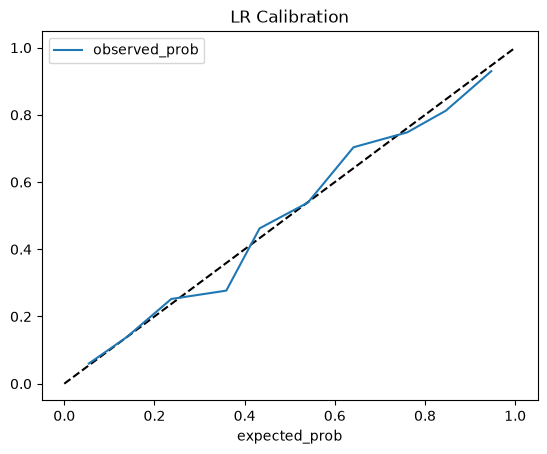

In [30]:
fig, ax = plt.subplots()

ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color="black", linestyle="--")
pod.binomial_goodness_of_fit_test().plot(x="expected_prob", y="observed_prob", title="LR Calibration", ax=ax)

plt.show()

In [31]:
psi_report = pod.generate_psi_report(n_bins=10)
print(psi_report.to_string(index=False))


=== System Population Stability Index Assessment ===
Total Portfolio PSI: 0.0016
Status: STABLE POPULATION (No significant shift detected)
 Lower Bound PD  Upper Bound PD  Train (Expected %)  Test (Actual %)  PSI Contribution  Min Credit Score  Max Credit Score
       0.000000        0.030543            9.713867        10.163479      2.034333e-04               587               886
       0.030543        0.062537           10.095635        10.317705      4.831860e-05               565               587
       0.062537        0.095683            8.799938         8.852560      3.137309e-06               552               565
       0.095683        0.111605           10.828320        10.857495      7.850200e-07               547               552
       0.111605        0.135297            9.929816         9.130167      6.713705e-04               541               547
       0.135297        0.176932           10.288447        10.657002      1.297150e-04               531               541

In [32]:
pod.fit()
test_pds = pod.calibrated_model.predict_proba(X_test)[:, 1]
test_scores = pod.convert_pd_to_credit_score(test_pds)

# Quick verification display mapping PD to Scores
score_samples = pd.DataFrame({
    'Actual Label': y_test,
    'Calibrated PD (%)': test_pds * 100,
    'Credit Bureau Point Score': test_scores
})
print("\n=== Credit Scoring Samples (Test Set) ===")
print(score_samples.head(10))


=== Credit Scoring Samples (Test Set) ===
   Actual Label  Calibrated PD (%)  Credit Bureau Point Score
0             0          22.270976                        523
1             1           6.511218                        564
2             0           5.328741                        570
3             0          12.654711                        543
4             1          96.487130                        392
5             0          12.354794                        544
6             1          11.763260                        545
7             0          15.218465                        537
8             0          39.857413                        499
9             0          10.641402                        549
